# Song Analysis
This notebook will aim to solve these questions:
- How do differences in release strategies (Album_type: album, single, compilation) affect artist engagement performance?
- Does the distribution of audio features (Danceability, Energy, Loudness, etc.) differ significantly across different release formats (Album_type)?
- Which audio features (e.g., Tempo, Valence, Loudness) correlate most strongly with Spotify Streams and YouTube Views?
- Do artists tend to keep their signature style consistently through out their tracks or vary?
- How do audience engagement (Likes, View, Comments) differs between artists on Youtube, and do they relate to those on Spotify?
- How the number of likes, views and comments effect each type of track (short, medium, long)?

# Importing Data and Libraries

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [105]:
file_path = '\\New folder\\Song_Analysis\\sample_data\\Spotify_Youtube.csv'
df = pd.read_csv(file_path)

In [106]:
df.head()

,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07
3,3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,...,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,True,True,4.346636e+08
4,4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,...,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,6.172597e+08


## Data Handling

In [107]:
songs = df.drop(columns=['Unnamed: 0','Url_spotify','Uri','Url_youtube','Description']).copy()

**NOTE**: The choice is to choose only Licensed song

In [108]:
songs = songs[songs['Licensed'] == True]
songs = songs.drop(columns = 'Licensed')

In [109]:
for i in songs.columns:
    print("\nunique values in {}:\n".format(i),songs[i].unique())


unique values in Artist:
 <StringArray>
[             'Gorillaz', 'Red Hot Chili Peppers',               '50 Cent',
             'Metallica',              'Coldplay',             'Daft Punk',
           'Linkin Park',             'Radiohead',                 'AC/DC',
       'Black Eyed Peas',
 ...
                   'IVE',                'Arcane',        'Sleepy Penguin',
                'AYLIVA',              'NewJeans',        'Grupo Frontera',
             'Jung Kook',           'LE SSERAFIM',              'ThxSoMch',
           'SICK LEGEND']
Length: 2010, dtype: str

unique values in Track:
 <StringArray>
[                               'Feel Good Inc.',
                               'Rhinestone Eyes',
 'New Gold (feat. Tame Impala and Bootie Brown)',
                            'On Melancholy Hill',
                                'Clint Eastwood',
                                          'DARE',
             'Cracker Island (feat. Thundercat)',
                               

**NOTE**: After selecting only Verified songs, official_videos now only have 1 variable - True.

In [110]:
songs = songs.drop(columns='official_video')

## Handling duplication

Method: Only dropping track that:
- All the characteristic of the song is similar

Since different song can have a same name:
- Tyler the Creator
- Charlie Puth

In [111]:
numeric_cols = songs[['Danceability', 'Energy', 'Loudness', 'Speechiness',
                     'Acousticness', 'Instrumentalness', 'Liveness',
                     'Valence', 'Tempo', 'Duration_ms']]
categorical_cols = songs[['Album_type','Key']]
song_popularity = songs[['Views','Stream','Comments','Likes']]
non_numeric_cols = songs[['Artist', 'Track', 'Album', 'Title', 'Channel']]

In [112]:
songs[numeric_cols.columns] = songs[numeric_cols.columns].astype('float64')
songs[categorical_cols.columns] = songs[categorical_cols.columns].astype('category')
songs[song_popularity.columns] = songs[song_popularity.columns].astype('float64')
songs[non_numeric_cols.columns] = songs[non_numeric_cols.columns].astype('string')

In [113]:
songs[songs.duplicated(subset=numeric_cols, keep=False)].sort_values(by=['Track','Album'])

,Artist,Track,Album,Album_type,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,...,Liveness,Valence,Tempo,Duration_ms,Title,Channel,Views,Likes,Comments,Stream
1517,thasup,!ly (feat. Coez),c@ra++ere s?ec!@le,album,0.765,0.726,7.0,-5.260,0.0505,0.2400,...,0.1260,0.690,126.556,206495.0,thasup - !ly (Visual Video) ft. Coez,thaSupremeVEVO,5.914198e+06,44528.0,814.0,26314102.0
12749,Coez,!ly (feat. Coez),c@ra++ere s?ec!@le,album,0.765,0.726,7.0,-5.260,0.0505,0.2400,...,0.1260,0.690,126.556,206495.0,thasup - !ly (Visual Video) ft. Coez,thaSupremeVEVO,5.914604e+06,44532.0,814.0,26314102.0
4210,Waylon Jennings,(Ghost) Riders in the Sky - Live at Nassau Col...,Live - American Outlaws,album,0.553,0.797,2.0,-8.762,0.0392,0.5360,...,0.9020,0.454,115.724,198133.0,(Ghost) Riders In the Sky (American Outlaws: L...,HighwaymenVEVO,5.925447e+07,432164.0,8590.0,8753204.0
6666,Kris Kristofferson,(Ghost) Riders in the Sky - Live at Nassau Col...,Live - American Outlaws,album,0.553,0.797,2.0,-8.762,0.0392,0.5360,...,0.9020,0.454,115.724,198133.0,(Ghost) Riders In the Sky (American Outlaws: L...,HighwaymenVEVO,5.925478e+07,432166.0,8590.0,8753204.0
12003,De La Ghetto,"1, 2, 3 (feat. Jason Derulo & De La Ghetto)",Mal De Amores,album,0.792,0.895,1.0,-3.112,0.0587,0.1650,...,0.0501,0.793,94.968,201526.0,"Sofia Reyes - 1, 2, 3 (feat. Jason Derulo & De...",Sofia Reyes,7.870894e+08,4782110.0,118961.0,589683929.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13582,Demi Lovato,Échame La Culpa,VIDA,album,0.733,0.897,0.0,-3.652,0.0389,0.0391,...,0.1170,0.649,96.006,173800.0,"Luis Fonsi, Demi Lovato - Échame La Culpa",LuisFonsiVEVO,2.245669e+09,10003295.0,335363.0,834445136.0
18610,Manuel Turizo,Éxtasis,Éxtasis,single,0.829,0.747,7.0,-3.511,0.1490,0.2760,...,0.3390,0.576,98.030,191607.0,Éxtasis - MTZ Manuel Turizo x Maria Becerra | ...,MTZ Manuel Turizo,1.636999e+07,203047.0,5467.0,44954838.0
19645,Maria Becerra,Éxtasis,Éxtasis,single,0.829,0.747,7.0,-3.511,0.1490,0.2760,...,0.3390,0.576,98.030,191607.0,Éxtasis - MTZ Manuel Turizo x Maria Becerra | ...,MTZ Manuel Turizo,1.637025e+07,203047.0,5467.0,45342529.0
11477,Guè,∞ LOVE (feat. Guè),"NOI, LORO, GLI ALTRI",album,0.726,0.828,7.0,-5.191,0.0710,0.1050,...,0.0873,0.307,125.002,218368.0,"Marracash, Guè - ∞ LOVE",MarracashVEVO,1.207319e+07,111698.0,3419.0,75480525.0


In [114]:
artist_ana = songs.copy()

In [115]:
songs = songs.drop_duplicates(subset=numeric_cols, keep='first')
print(f"Dropping dup: {len(songs)}")
songs.info()

Dropping dup: 12943
<class 'pandas.DataFrame'>
Index: 12943 entries, 0 to 20717
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Artist            12943 non-null  string  
 1   Track             12943 non-null  string  
 2   Album             12943 non-null  string  
 3   Album_type        12943 non-null  category
 4   Danceability      12942 non-null  float64 
 5   Energy            12942 non-null  float64 
 6   Key               12942 non-null  category
 7   Loudness          12942 non-null  float64 
 8   Speechiness       12942 non-null  float64 
 9   Acousticness      12942 non-null  float64 
 10  Instrumentalness  12942 non-null  float64 
 11  Liveness          12942 non-null  float64 
 12  Valence           12942 non-null  float64 
 13  Tempo             12942 non-null  float64 
 14  Duration_ms       12942 non-null  float64 
 15  Title             12943 non-null  string  
 16  Channel           

## Null Handling

In [116]:
null_song = songs[songs[numeric_cols.columns].isnull().any(axis=1)]

**NOTE**: Only 1 song has null variable in song's characteristic
=> Drop that track would be the best choice in this situation

In [117]:
songs = songs.drop(null_song.index)

# Data Overview

## Song Overview

In [118]:
df.describe()

,Unnamed: 0,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Views,Likes,Comments,Stream
count,20718.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,2.071600e+04,2.024800e+04,2.017700e+04,2.014900e+04,2.014200e+04
mean,10358.500000,0.619777,0.635250,5.300348,-7.671680,0.096456,0.291535,0.055962,0.193521,0.529853,120.638340,2.247176e+05,9.393782e+07,6.633411e+05,2.751899e+04,1.359422e+08
std,5980.915774,0.165272,0.214147,3.576449,4.632749,0.111960,0.286299,0.193262,0.168531,0.245441,29.579018,1.247905e+05,2.746443e+08,1.789324e+06,1.932347e+05,2.441321e+08
min,0.000000,0.000000,0.000020,0.000000,-46.251000,0.000000,0.000001,0.000000,0.014500,0.000000,0.000000,3.098500e+04,0.000000e+00,0.000000e+00,0.000000e+00,6.574000e+03
25%,5179.250000,0.518000,0.507000,2.000000,-8.858000,0.035700,0.045200,0.000000,0.094100,0.339000,97.002000,1.800095e+05,1.826002e+06,2.158100e+04,5.090000e+02,1.767486e+07
50%,10358.500000,0.637000,0.666000,5.000000,-6.536000,0.050500,0.193000,0.000002,0.125000,0.537000,119.965000,2.132845e+05,1.450110e+07,1.244810e+05,3.277000e+03,4.968298e+07
75%,15537.750000,0.740250,0.798000,8.000000,-4.931000,0.103000,0.477250,0.000463,0.237000,0.726250,139.935000,2.524430e+05,7.039975e+07,5.221480e+05,1.436000e+04,1.383581e+08
max,20717.000000,0.975000,1.000000,11.000000,0.920000,0.964000,0.996000,1.000000,1.000000,0.993000,243.372000,4.676058e+06,8.079649e+09,5.078865e+07,1.608314e+07,3.386520e+09


In [119]:
spotify_info = songs[numeric_cols.columns.union(['Stream','Key'])]
youtube_info = songs[numeric_cols.columns.union(['Views','Likes','Comments','Key'])]

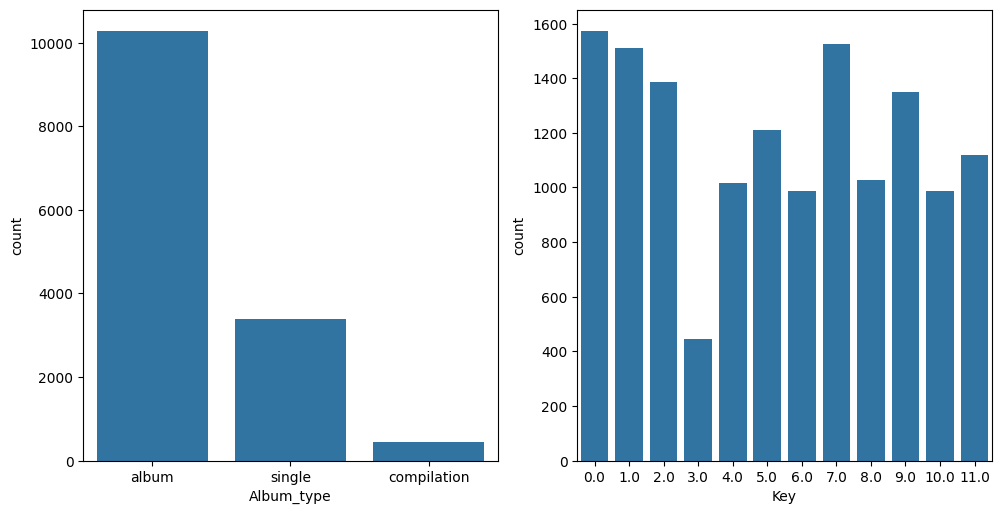

In [120]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in categorical_cols.columns:
    if plotnumber <= 12:
        ax = plt.subplot(3, 4, plotnumber)
        sns.countplot(x=categorical_cols[column], ax=ax)
        plt.xlabel(column)

    plotnumber += 1

plt.tight_layout()

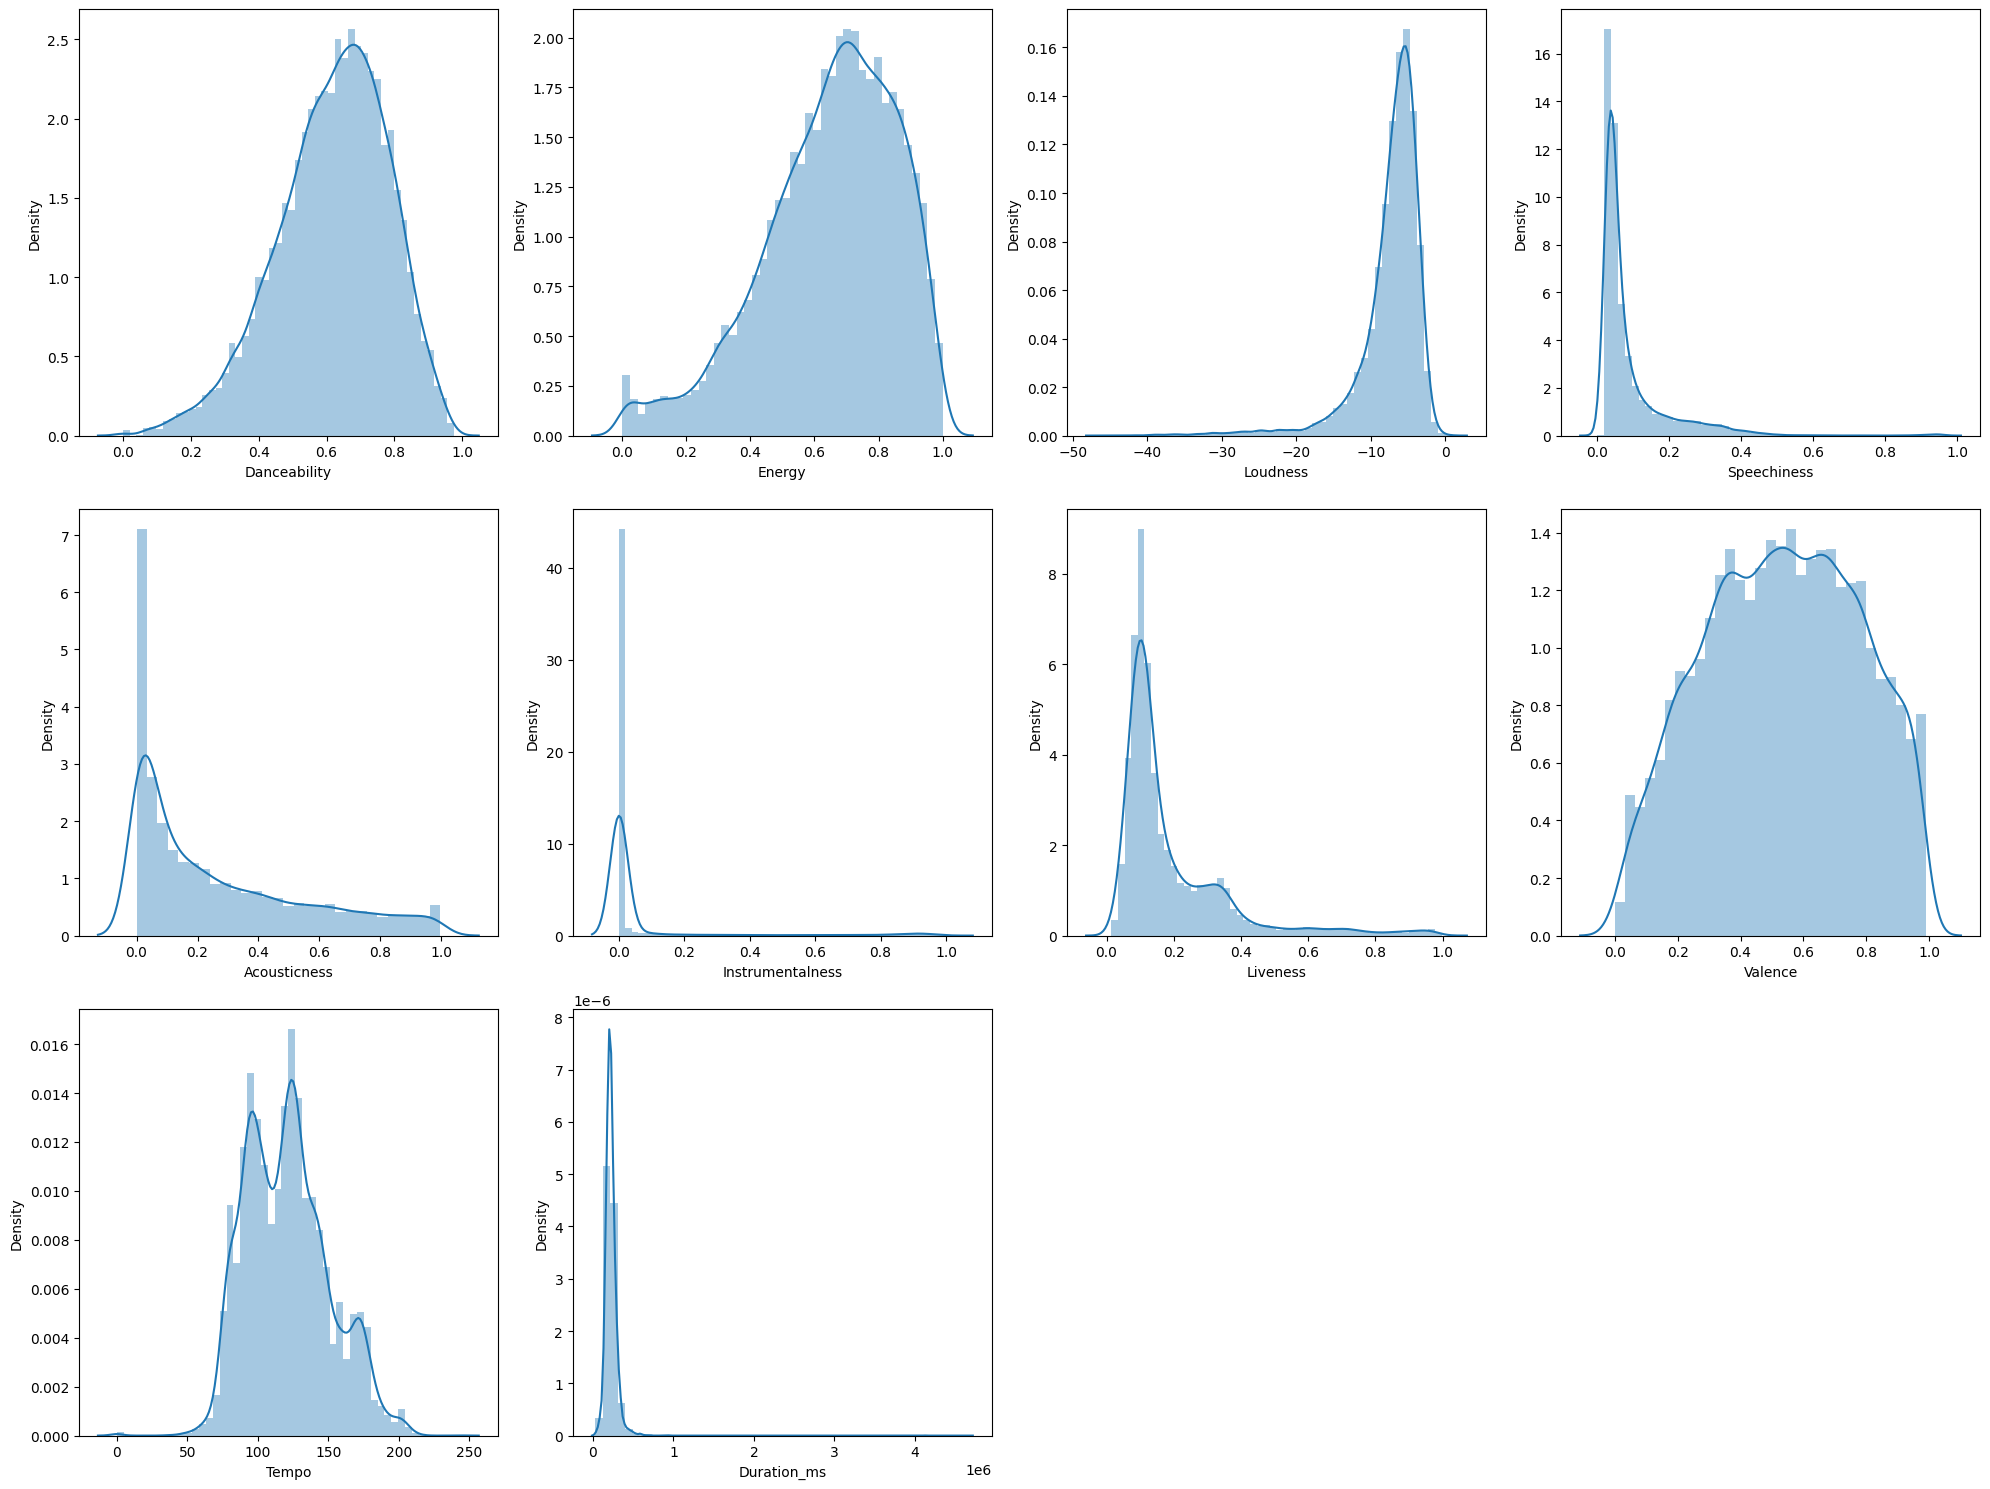

In [121]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in numeric_cols.columns:
    if plotnumber <= 12:
        ax = plt.subplot(3, 4, plotnumber)
        sns.distplot(spotify_info[column])
        plt.xlabel(column)

    plotnumber += 1

plt.tight_layout()
plt.show()

**NOTE**: From the overview plot we can clearly see that:
- Right skewed: Speechiness, Acousticness, Instrumentalness, Liveness, Duration_ms
- Left skewed: Danceability, Energy, Loudness

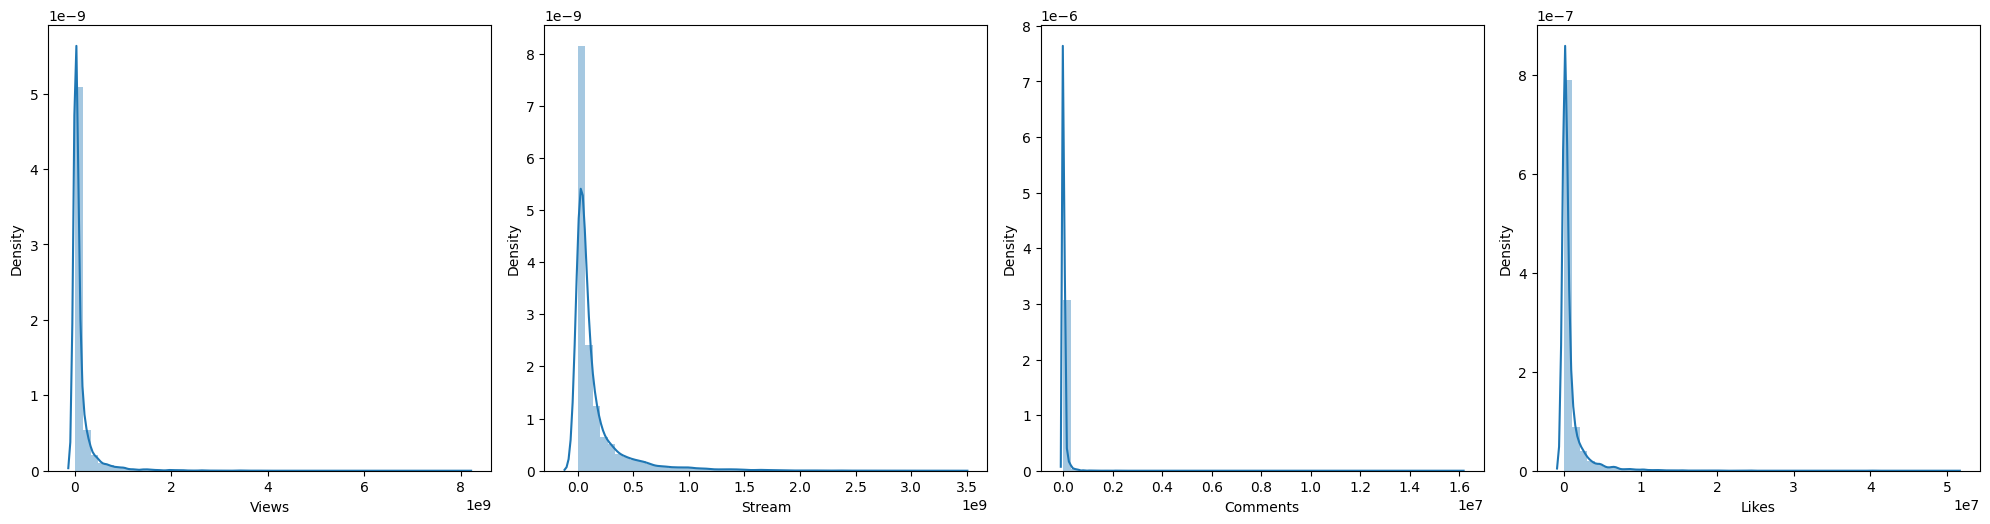

In [122]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in song_popularity.columns:
    if plotnumber <= 12:
        ax = plt.subplot(3, 4, plotnumber)
        sns.distplot(song_popularity[column])
        plt.xlabel(column)

    plotnumber += 1

plt.tight_layout()

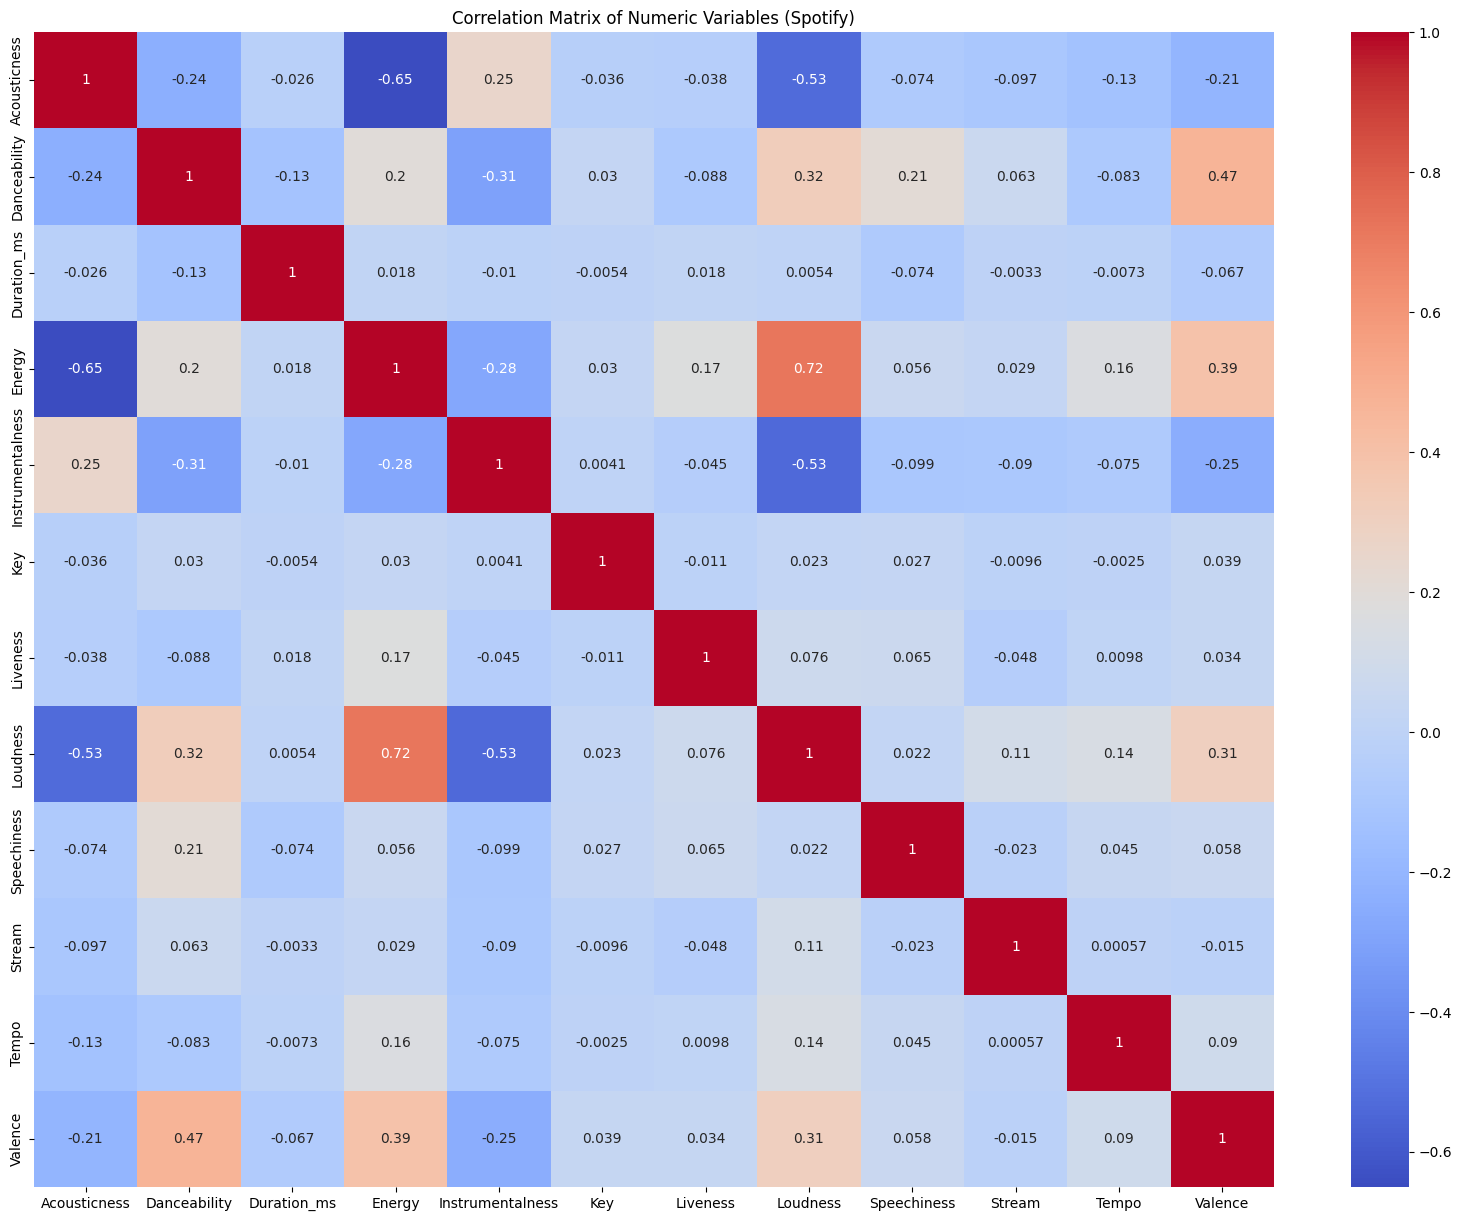

In [123]:
plt.figure(figsize=(20,15))
sns.heatmap(spotify_info.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Variables (Spotify)')
plt.show()

**Note**: Based purely on the heatmap, we can tell that there is not a song characteristic that heavily impact on the number of Stream

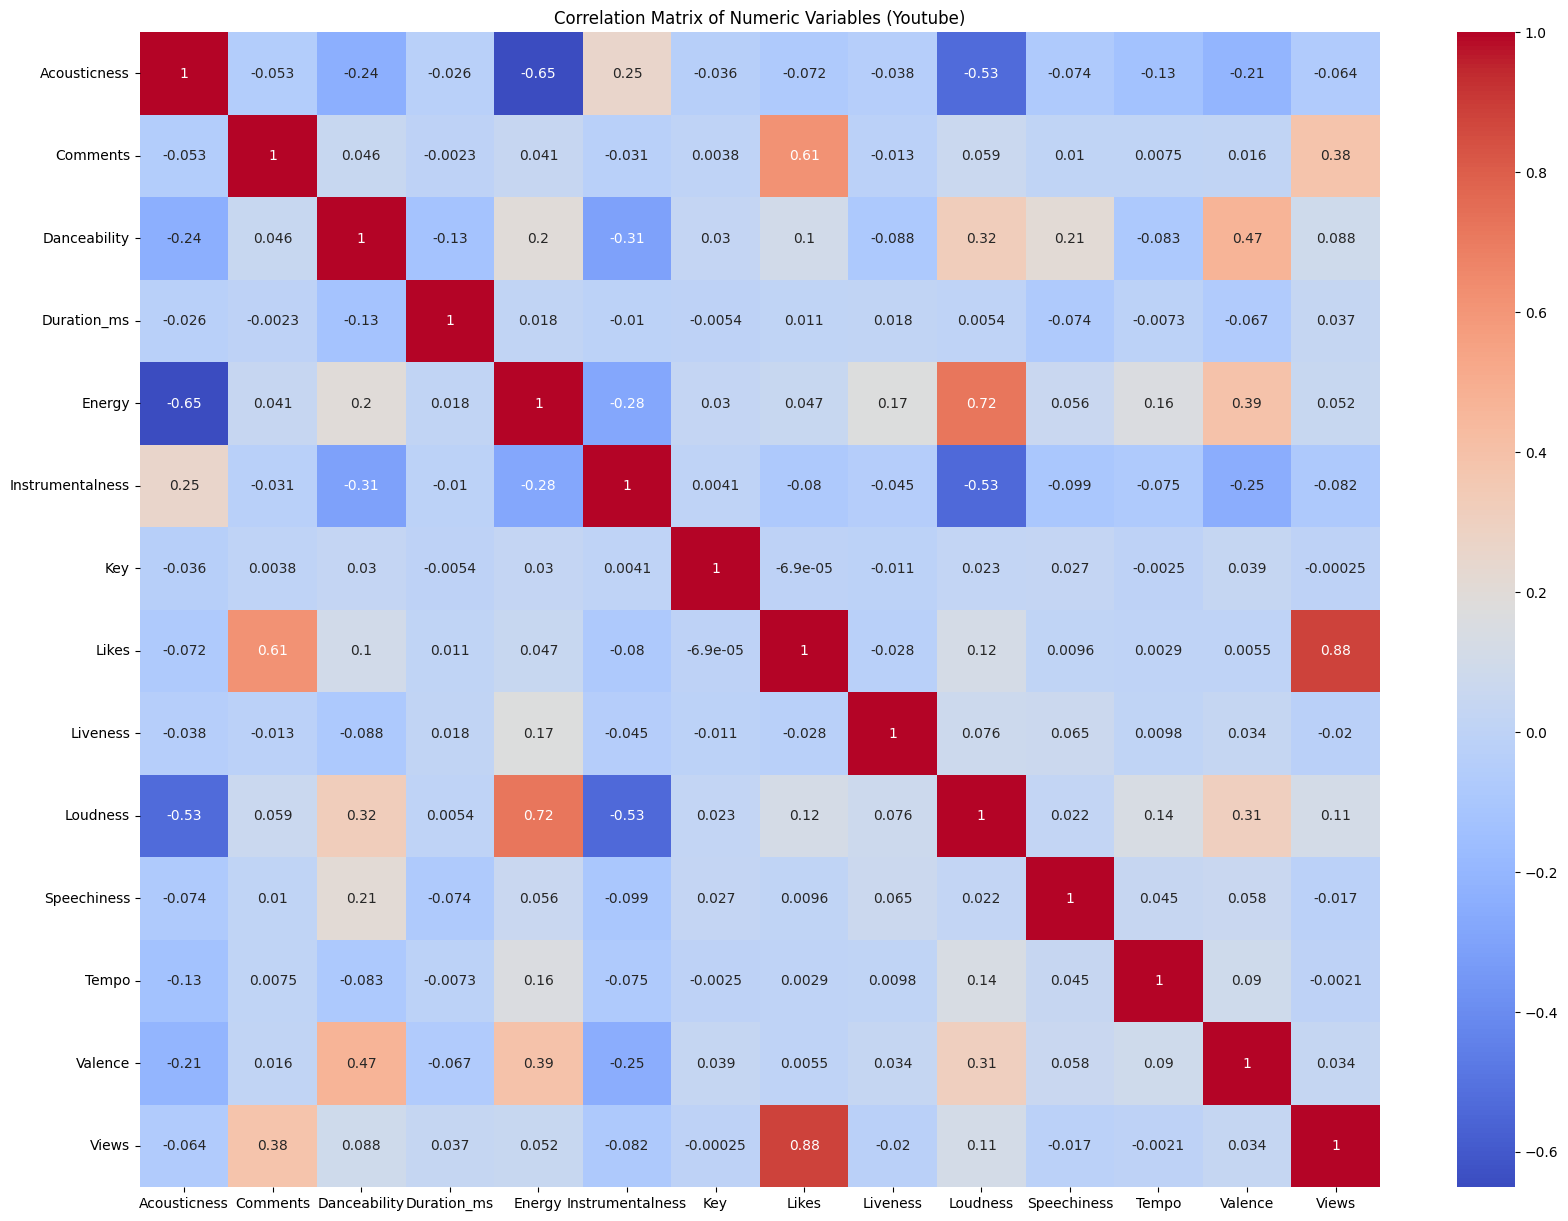

In [124]:
plt.figure(figsize=(20,15))
sns.heatmap(youtube_info.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Variables (Youtube)')
plt.show()

**NOTE**: Similar to Spotify, there is no song characteristic heavily affect on the performance of a song.

**WHAT WE HAVE**: Based on the overview, we know that:
- There is no feature of a song that have a strong correlation with song popularity
- A lot of features seems to play a similar role => It is important to feature selection
- Most of the song is a part of an album => Might indicate that many songs might have quite relavant attribute

### Artist Album

In [125]:
album_groupby_artist = artist_ana.groupby('Artist')[['Album']].nunique().sort_values(by='Album', ascending=False).reset_index()
songs_groupby_artist = artist_ana.groupby('Artist')[['Track']].nunique().sort_values(by='Track', ascending=False).reset_index()
stream_groupby_artist = artist_ana.groupby('Artist')[['Stream']].sum().sort_values(by='Stream', ascending=False).reset_index()
view_groupby_artist = artist_ana.groupby('Artist')[['Views']].sum().sort_values(by='Views', ascending=False).reset_index()

In [126]:
artist_overall = pd.merge(album_groupby_artist, songs_groupby_artist, on='Artist')
artist_overall = pd.merge(artist_overall, stream_groupby_artist, on='Artist')
artist_overall = pd.merge(artist_overall, view_groupby_artist, on='Artist')
artist_overall['Avg_Stream'] = artist_overall['Stream'] / artist_overall['Track']
artist_overall['Avg_View'] = artist_overall['Views'] / artist_overall['Track']
artist_overall = artist_overall.sort_values(by='Stream', ascending=False)
artist_overall.head(10)

,Artist,Album,Track,Stream,Views,Avg_Stream,Avg_View
577,Ed Sheeran,6,10,1.439488e+10,1.546021e+10,1.439488e+09,1.546021e+09
1238,Post Malone,4,8,1.243216e+10,6.093324e+09,1.554020e+09,7.616655e+08
936,Dua Lipa,5,9,1.231142e+10,7.511817e+09,1.367936e+09,8.346463e+08
1399,Imagine Dragons,4,10,1.185831e+10,9.093785e+09,1.185831e+09,9.093785e+08
94,Coldplay,9,10,1.177848e+10,9.997278e+09,1.177848e+09,9.997278e+08
1095,The Weeknd,5,7,1.171657e+10,6.919935e+09,1.673795e+09,9.885622e+08
284,Ariana Grande,8,10,1.085741e+10,4.458246e+09,1.085741e+09,4.458246e+08
524,Billie Eilish,7,9,1.055823e+10,4.800023e+09,1.173136e+09,5.333359e+08
508,The Chainsmokers,7,10,1.039670e+10,5.442224e+09,1.039670e+09,5.442224e+08
1261,Bruno Mars,4,9,9.963335e+09,1.023184e+10,1.107037e+09,1.136871e+09


In [127]:
songs_groupby_artist[songs_groupby_artist['Artist'] == 'Kanye West']

,Artist,Track
489,Kanye West,9


In [128]:
artist_ana[artist_ana['Artist'] == 'Kanye West']

,Artist,Track,Album,Album_type,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,...,Liveness,Valence,Tempo,Duration_ms,Title,Channel,Views,Likes,Comments,Stream
330,Kanye West,Bound 2,Yeezus,album,0.367,0.665,1.0,-2.821,0.0465,0.14500,...,0.1130,0.310,148.913,229147.0,Kanye West - Bound 2 (Explicit),KanyeWestVEVO,105206228.0,1105989.0,129255.0,5.781156e+08
331,Kanye West,Heartless,808s & Heartbreak,album,0.790,0.647,10.0,-5.983,0.1360,0.05150,...,0.2480,0.654,87.999,211000.0,Kanye West - Heartless,KanyeWestVEVO,200458945.0,1310078.0,63150.0,7.207564e+08
332,Kanye West,Flashing Lights,Graduation,album,0.639,0.628,6.0,-7.578,0.0399,0.03810,...,0.3860,0.430,90.482,237507.0,Kanye West - Flashing Lights ft. Dwele,KanyeWestVEVO,123256878.0,959510.0,35828.0,5.432864e+08
333,Kanye West,Ni**as In Paris,Watch The Throne (Deluxe),album,0.789,0.858,1.0,-5.542,0.3110,0.12700,...,0.3490,0.775,140.022,219333.0,Jay-Z & Kanye West - Ni**as In Paris (Explicit),KanyeWestVEVO,374189685.0,2521768.0,103200.0,1.054471e+09
334,Kanye West,Father Stretch My Hands Pt. 1,The Life Of Pablo,album,0.724,0.573,7.0,-4.113,0.0549,0.11800,...,0.5380,0.438,113.088,135920.0,Father Stretch My Hands Pt. 1,Kanye West - Topic,47207589.0,587832.0,6406.0,6.271673e+08
335,Kanye West,Stronger,Graduation,album,0.617,0.717,10.0,-7.858,0.1530,0.00564,...,0.4080,0.490,103.992,311867.0,Kanye West - Stronger,KanyeWestVEVO,432609094.0,2878369.0,156021.0,1.123296e+09
336,Kanye West,I Wonder,Graduation,album,0.542,0.466,0.0,-8.665,0.0831,0.14100,...,0.1250,0.124,191.385,243440.0,I Wonder,Kanye West - Topic,13652003.0,161439.0,692.0,3.028915e+08
338,Kanye West,Homecoming,Graduation,album,0.667,0.747,1.0,-7.059,0.1890,0.33700,...,0.1150,0.918,86.917,203493.0,Kanye West - Homecoming,KanyeWestVEVO,101552405.0,540229.0,25030.0,3.790999e+08
339,Kanye West,Gold Digger,Late Registration,album,0.629,0.696,1.0,-5.572,0.3480,0.01950,...,0.0554,0.623,93.034,207627.0,Kanye West - Gold Digger ft. Jamie Foxx,KanyeWestVEVO,323806093.0,1797312.0,71502.0,8.533815e+08


**NOTE**: Based on the previous finding, we are sure that dataset only contain track that does get uploaded to both Spotify and Youtube

=> So there is no point of analyze Album in general

**SONGS**



In [129]:
from sklearn.preprocessing import MinMaxScaler
cols = ['Danceability', 'Energy', 'Loudness', 'Valence', 'Tempo', 'Acousticness', 'Instrumentalness']
scaler = MinMaxScaler()
songs_scaled = songs.copy()
songs_scaled[cols] = scaler.fit_transform(songs[cols])

**NOTE**: Here we believe that these features capture and reflect the musical style of an artist. 

In [130]:
songs_scaled.describe()

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Views,Likes,Comments,Stream
count,12942.000000,12942.000000,12942.000000,12942.000000,12942.000000,12942.000000,12942.000000,12942.000000,12942.000000,1.294200e+04,1.294200e+04,1.291600e+04,1.290500e+04,1.259700e+04
mean,0.634204,0.647367,0.824287,0.090639,0.273707,0.049585,0.191717,0.536476,0.497139,2.242411e+05,1.148789e+08,7.880292e+05,3.393559e+04,1.491966e+08
std,0.167415,0.209072,0.092144,0.102709,0.281683,0.181271,0.166858,0.245925,0.121701,9.287631e+04,2.973561e+08,1.900404e+06,2.225747e+05,2.596007e+08
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014500,0.000000,0.000000,3.098500e+04,0.000000e+00,0.000000e+00,0.000000e+00,6.574000e+03
25%,0.529231,0.522240,0.800423,0.035200,0.036746,0.000000,0.093600,0.346115,0.398913,1.837810e+05,4.354554e+06,4.742625e+04,1.078000e+03,1.909058e+07
50%,0.651282,0.675993,0.845689,0.049500,0.170682,0.000002,0.124000,0.542886,0.493042,2.154245e+05,2.469527e+07,1.902745e+05,5.100000e+03,5.448312e+07
75%,0.756923,0.805996,0.877658,0.095600,0.445783,0.000400,0.235000,0.731584,0.575194,2.530768e+05,9.559324e+07,6.700620e+05,1.898500e+04,1.543113e+08
max,1.000000,1.000000,1.000000,0.964000,1.000000,1.000000,0.997000,1.000000,1.000000,4.676058e+06,8.079647e+09,5.078863e+07,1.608314e+07,3.386520e+09


In [131]:
mean_artist = songs_scaled.groupby('Artist')[cols].transform('mean')
for col in cols:
    songs_scaled[f'{col}_mean'] = songs_scaled[col] - mean_artist[col]
songs_scaled.head(10)

,Artist,Track,Album,Album_type,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,...,Likes,Comments,Stream,Danceability_mean,Energy_mean,Loudness_mean,Valence_mean,Tempo_mean,Acousticness_mean,Instrumentalness_mean
0,Gorillaz,Feel Good Inc.,Demon Days,album,0.838974,0.704994,6.0,0.838905,0.1770,0.008392,...,6220896.0,169907.0,1.040235e+09,0.112436,-0.100627,-0.016438,0.053481,0.024751,-0.019330,-0.101410
1,Gorillaz,Rhinestone Eyes,Plastic Beach,album,0.693333,0.702994,8.0,0.857222,0.0302,0.087248,...,1079128.0,31003.0,3.100837e+08,-0.033205,-0.102627,0.001879,0.134208,-0.163430,0.059525,-0.103053
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,0.712821,0.922998,1.0,0.897183,0.0522,0.042670,...,282142.0,7399.0,6.306347e+07,-0.013718,0.117377,0.041840,-0.169526,-0.100756,0.014947,-0.056840
3,Gorillaz,On Melancholy Hill,Plastic Beach,album,0.706667,0.738995,2.0,0.857328,0.0260,0.000014,...,1788577.0,55229.0,4.346636e+08,-0.019872,-0.066626,0.001985,-0.142281,-0.049768,-0.027709,0.405260
4,Gorillaz,Clint Eastwood,Gorillaz,album,0.680000,0.693994,10.0,0.797609,0.1710,0.025401,...,6197318.0,155930.0,6.172597e+08,-0.046538,-0.111627,-0.057734,-0.195762,0.145529,-0.002322,-0.103740
5,Gorillaz,DARE,Demon Days,album,0.779487,0.890998,11.0,0.856437,0.0372,0.022991,...,1844658.0,72008.0,3.238503e+08,0.052949,0.085377,0.001094,0.249243,-0.050422,-0.004732,-0.016840
8,Gorillaz,Cracker Island (feat. Thundercat),Cracker Island (feat. Thundercat),single,0.760000,0.912998,2.0,0.909690,0.0465,0.003443,...,739527.0,20296.0,4.267190e+07,0.033462,0.107377,0.054347,-0.076690,-0.051457,-0.024280,-0.000740
9,Gorillaz,Dirty Harry,Demon Days,album,0.641026,0.876998,10.0,0.828369,0.1620,0.031625,...,1386920.0,39240.0,1.910747e+08,-0.085513,0.071376,-0.026974,0.147326,0.245553,0.003902,-0.022640
10,Red Hot Chili Peppers,Californication,Californication (Deluxe Edition),album,0.607179,0.766995,9.0,0.921392,0.0270,0.002107,...,4394471.0,121452.0,1.055738e+09,0.030564,-0.035301,0.058472,-0.195863,-0.010973,-0.037550,-0.009767
11,Red Hot Chili Peppers,Under the Bridge,Blood Sugar Sex Magik (Deluxe Edition),album,0.573333,0.344987,4.0,0.694389,0.0459,0.057830,...,1213572.0,32761.0,1.061751e+09,-0.003282,-0.457309,-0.168532,-0.064682,-0.059878,0.018173,-0.011312


In [132]:
print(songs_scaled[cols].isnull().sum())

Danceability        0
Energy              0
Loudness            0
Valence             0
Tempo               0
Acousticness        0
Instrumentalness    0
dtype: int64


In [133]:
artist_counts = songs_scaled.groupby('Artist')['Track'].count()
valid_artists = artist_counts[artist_counts >= 3].index
df_filtered = songs_scaled[songs_scaled['Artist'].isin(valid_artists)]

In [134]:
std_artist = df_filtered.groupby('Artist')[cols].std()
std_artist['Diversity_Score'] = std_artist.mean(axis=1)

In [135]:
result = std_artist[['Diversity_Score']].sort_values('Diversity_Score', ascending=False)
print(result)

                   Diversity_Score
Artist                            
Dybbukk                   0.314072
Miggy Dela Rosa           0.289412
Traditional               0.274967
The Alchemist             0.256029
11:11 Music Group         0.251082
...                            ...
Cascada                   0.041239
Grupo Frontera            0.040672
MK                        0.038896
Pierce The Veil           0.033813
Código FN                 0.031109

[1803 rows x 1 columns]


**NOTE**: We can clearly see the diversity in each artist style compare to others

In [136]:
art_mean = (songs_scaled[songs_scaled['Artist'] == 'Kanye West'][cols].mean())

In [137]:
stats = (songs_scaled[(songs_scaled['Artist'] == 'Kanye West') & (songs_scaled['Track'] == 'Stronger')][cols].iloc[0])

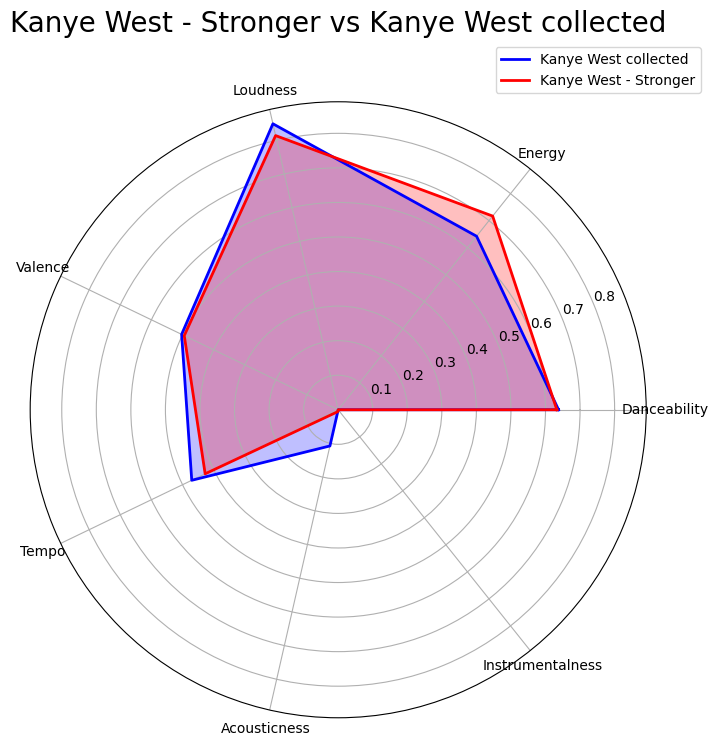

In [153]:
labels = cols
mean_values = art_mean.values.tolist()
stats_values = stats.values.tolist()

mean_values += mean_values[:1]
stats_values += stats_values[:1]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, mean_values, color='blue', linewidth=2, label='Kanye West collected')
ax.fill(angles, mean_values, color='blue', alpha=0.25)

ax.plot(angles, stats_values, color='red', linewidth=2, label='Kanye West - Stronger')
ax.fill(angles, stats_values, color='red', alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plot_title = 'Kanye West - Stronger vs Kanye West collected'
plt.title(plot_title, size=20, color='black', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.show()

**NOTE**: We can see the consistency and diversity of each artist musical style

In [139]:
songs[['Likes', 'Views', 'Comments']].isnull().sum()

Likes       26
Views        0
Comments    37
dtype: int64

In [140]:
missing_values = songs[songs[['Likes', 'Views', 'Comments']].isnull().any(axis=1)]
print(f"{len(missing_values)}")
print(missing_values)

56
                      Artist  \
970            Bibi und Tina   
1906    Rahat Fateh Ali Khan   
4514                 Placebo   
4862             The Wiggles   
4864             The Wiggles   
4865             The Wiggles   
4866             The Wiggles   
4869             The Wiggles   
4871             The Wiggles   
6585         BUMP OF CHICKEN   
6922                  ARASHI   
6923                  ARASHI   
6925                  ARASHI   
6928                  ARASHI   
6929                  ARASHI   
7771                   Kelis   
7967          Rolf Zuckowski   
7969          Rolf Zuckowski   
7975          Rolf Zuckowski   
7988               Rammstein   
7989               Rammstein   
7990               Rammstein   
7992               Rammstein   
7993               Rammstein   
7994               Rammstein   
7996               Rammstein   
8035            David Guetta   
8294           Blake Shelton   
9442                Chevelle   
9459           Steve Edwards   
9778 

In [141]:
songs = songs.drop(missing_values.index).reset_index(drop=True)

In [142]:
songs[['Likes', 'Views', 'Comments']].isnull().sum()

Likes       0
Views       0
Comments    0
dtype: int64

In [143]:
songs['Engagement_like'] = songs['Likes'] / songs['Views']
songs['Engagement_comment'] = songs['Comments'] / songs['Views']

In [144]:
songs[['Engagement_like', 'Engagement_comment', 'Stream']].corr()

,Engagement_like,Engagement_comment,Stream
Engagement_like,1.000000,0.568009,-0.118839
Engagement_comment,0.568009,1.000000,-0.049458
Stream,-0.118839,-0.049458,1.000000


**NOTE** : We used the median to fill in missing values in the Views, Likes, and Comments columns. This is because some songs may have unusually high view and like counts (such as viral hits). 

In [152]:
df['Duration_ms'].isnull().sum()

np.int64(2)

In [146]:
df['Duration_ms'].describe()

count    2.071600e+04
mean     2.247176e+05
std      1.247905e+05
min      3.098500e+04
25%      1.800095e+05
50%      2.132845e+05
75%      2.524430e+05
max      4.676058e+06
Name: Duration_ms, dtype: float64

In [147]:
Q1 = df['Duration_ms'].quantile(0.25)
Q3 = df['Duration_ms'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Duration_ms_final'] = df['Duration_ms'].clip(lower, upper)

**NOTE** : As viewed before, the duration feature is right skewed and we want to keep using without dropping any songs.

In [ ]:
print(df['Duration_ms_final'].min())
print(df['Duration_ms_final'].max())

71359.25
361093.25
0.33    191258.0
0.66    235420.3
Name: Duration_ms_final, dtype: float64


In [ ]:
df['Duration_Type'] = pd.cut(
    df['Duration_ms_final'],   
    bins=[
        df['Duration_ms_final'].min(),
        df['Duration_ms_final'].quantile(0.33),
        df['Duration_ms_final'].quantile(0.66),
        df['Duration_ms_final'].max()
    ],
    labels=['Short', 'Medium', 'Long'],
    include_lowest=True
)
print(df['Duration_Type'].value_counts())

Duration_Type
Long      7044
Short     6837
Medium    6835
Name: count, dtype: int64


In [150]:
df.groupby('Duration_Type')[['Views', 'Likes', 'Stream']].mean()

,Views,Likes,Stream
Duration_Type,,,
Short,5.488078e+07,483320.897548,1.125908e+08
Medium,1.222824e+08,866955.629249,1.673527e+08
Long,1.038913e+08,637717.860350,1.280618e+08
